# 02. RNN & LSTM 감정분석

**모델**: SimpleRNN, LSTM, BiLSTM (Keras)  

## 진행 순서
1. 환경 설정 및 데이터 로드
2. 토큰화 + 패딩
3. SimpleRNN 모델 (베이스라인)
4. LSTM 모델
5. BiLSTM 모델 (양방향)
6. 세 모델 비교

### 0. Google Drive 마운트 및 경로 설정

In [1]:
# Google Drive 마운트
import os, sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/sentiment_analysis'
    IN_COLAB = True
except ImportError:
    # 로컬 환경에서 실행할 경우: 현재 디렉토리 기준
    PROJECT_DIR = '.'
    IN_COLAB = False
    print('로컬 환경에서 실행 중')

# 하위 폴더 정의
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# utils.py import 경로 추가
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

print(f'프로젝트 경로: {PROJECT_DIR}')
print(f'데이터 경로 : {DATA_DIR}')
print(f'결과 경로  : {RESULTS_DIR}')

Mounted at /content/drive
프로젝트 경로: /content/drive/MyDrive/sentiment_analysis
데이터 경로 : /content/drive/MyDrive/sentiment_analysis/data
결과 경로  : /content/drive/MyDrive/sentiment_analysis/results


### 1. 환경 설정

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, json

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Bidirectional,
    Dense, Dropout, GlobalMaxPooling1D, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from utils import (load_data, evaluate_model, plot_confusion_matrix,
                   show_misclassified, LABEL_NAMES)

# 재현성
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

print(f'TF version: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 2. 데이터 로드 및 토큰화

In [3]:
X_train_text, y_train, X_test_text, y_test = load_data(
    train_path=os.path.join(DATA_DIR, 'train_clean.csv'),
    test_path=os.path.join(DATA_DIR, 'test_clean.csv'),
    text_col='text_classic'
)

print(f'Train: {len(X_train_text):,} / Test: {len(X_test_text):,}')
print(f'\n예시 (text_classic):')
for i in range(3):
    print(f'  [{LABEL_NAMES[y_train[i]]}] {X_train_text[i][:90]}')

Train: 27,477 / Test: 3,534

예시 (text_classic):
  [neutral] i d have responded, if i were going
  [negative] soo sad i will miss you here in san diego!!
  [negative] my boss is bullying me..


In [4]:
# 하이퍼파라미터
VOCAB_SIZE = 20000   # EDA에서 본 어휘 크기 고려
MAX_LEN = 40         # 트윗 99%가 33단어 이하 → 40으로 패딩
EMBED_DIM = 128

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test,  num_classes=3)

print(f'Vocab 실제 크기: {len(tokenizer.word_index):,}')
print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad  shape: {X_test_pad.shape}')

Vocab 실제 크기: 24,495
X_train_pad shape: (27477, 40)
X_test_pad  shape: (3534, 40)


### 3. SimpleRNN 모델 (베이스라인)

가장 기본적인 순환 신경망. 장기 의존성 학습에 약한 것으로 알려져 있음 → 비교 기준.

In [5]:
def build_simple_rnn():
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
        SpatialDropout1D(0.3),
        SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(3, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

rnn_model = build_simple_rnn()
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

t0 = time.time()
history_rnn = rnn_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=8,
    batch_size=128,
    callbacks=[es],
    verbose=1,
)
rnn_time = time.time() - t0
print(f'\n⏱ SimpleRNN 학습 시간: {rnn_time:.1f}s')

Epoch 1/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.3813 - loss: 1.1056 - val_accuracy: 0.4247 - val_loss: 1.0819
Epoch 2/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4019 - loss: 1.0894 - val_accuracy: 0.4247 - val_loss: 1.0828
Epoch 3/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4016 - loss: 1.0888 - val_accuracy: 0.4247 - val_loss: 1.0833

⏱ SimpleRNN 학습 시간: 15.9s


In [7]:
y_pred_rnn = rnn_model.predict(X_test_pad, verbose=0).argmax(axis=1)
result_rnn = evaluate_model(y_test, y_pred_rnn, 'SimpleRNN')
result_rnn['train_time_sec'] = rnn_time


📊 SimpleRNN 평가 결과
  Accuracy        : 0.4046
  F1 (macro)      : 0.1920
  F1 (weighted)   : 0.2331
  Precision macro : 0.1349
  Recall macro    : 0.3333

--- Classification Report ---
              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000      1001
     neutral     0.4046    1.0000    0.5761      1430
    positive     0.0000    0.0000    0.0000      1103

    accuracy                         0.4046      3534
   macro avg     0.1349    0.3333    0.1920      3534
weighted avg     0.1637    0.4046    0.2331      3534



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 4. LSTM 모델

In [8]:
def build_lstm():
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
        SpatialDropout1D(0.3),
        LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(3, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_model = build_lstm()
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
t0 = time.time()
history_lstm = lstm_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=8,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
    verbose=1,
)
lstm_time = time.time() - t0
print(f'\n⏱ LSTM 학습 시간: {lstm_time:.1f}s')

Epoch 1/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 43s 163ms/step - accuracy: 0.3956 - loss: 1.0906 - val_accuracy: 0.4247 - val_loss: 1.0832
Epoch 2/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 31s 158ms/step - accuracy: 0.4028 - loss: 1.0874 - val_accuracy: 0.4436 - val_loss: 1.0499
Epoch 3/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 34s 173ms/step - accuracy: 0.4704 - loss: 1.0245 - val_accuracy: 0.4825 - val_loss: 1.0264
Epoch 4/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 38s 159ms/step - accuracy: 0.4856 - loss: 1.0217 - val_accuracy: 0.4905 - val_loss: 1.0245
Epoch 5/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - accuracy: 0.4754 - loss: 1.0215 - val_accuracy: 0.4654 - val_loss: 1.0315
Epoch 6/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 40s 156ms/step - accuracy: 0.4623 - loss: 1.0228 - val_accuracy: 0.4618 - val_loss: 1.0309

⏱ LSTM 학습 시간: 227.3s


In [10]:
y_pred_lstm = lstm_model.predict(X_test_pad, verbose=0).argmax(axis=1)
result_lstm = evaluate_model(y_test, y_pred_lstm, 'LSTM')
result_lstm['train_time_sec'] = lstm_time


📊 LSTM 평가 결과
  Accuracy        : 0.4805
  F1 (macro)      : 0.3625
  F1 (weighted)   : 0.3933
  Precision macro : 0.3630
  Recall macro    : 0.4272

--- Classification Report ---
              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000      1001
     neutral     0.4386    0.8699    0.5832      1430
    positive     0.6504    0.4116    0.5042      1103

    accuracy                         0.4805      3534
   macro avg     0.3630    0.4272    0.3625      3534
weighted avg     0.3805    0.4805    0.3933      3534



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 5. BiLSTM (양방향 LSTM)

문장을 앞→뒤, 뒤→앞 양방향으로 읽어 양쪽 문맥을 모두 활용.

In [11]:
def build_bilstm():
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.2)),
        GlobalMaxPooling1D(),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(3, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

bilstm_model = build_bilstm()
bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
t0 = time.time()
history_bilstm = bilstm_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=8,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
    verbose=1,
)
bilstm_time = time.time() - t0
print(f'\n⏱ BiLSTM 학습 시간: {bilstm_time:.1f}s')

Epoch 1/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5468 - loss: 0.9210 - val_accuracy: 0.6954 - val_loss: 0.7115
Epoch 2/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7359 - loss: 0.6478 - val_accuracy: 0.7267 - val_loss: 0.6627
Epoch 3/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8003 - loss: 0.5281 - val_accuracy: 0.7267 - val_loss: 0.6866
Epoch 4/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8409 - loss: 0.4419 - val_accuracy: 0.7140 - val_loss: 0.7306

⏱ BiLSTM 학습 시간: 14.6s


In [13]:
y_pred_bilstm = bilstm_model.predict(X_test_pad, verbose=0).argmax(axis=1)
result_bilstm = evaluate_model(y_test, y_pred_bilstm, 'BiLSTM')
result_bilstm['train_time_sec'] = bilstm_time


📊 BiLSTM 평가 결과
  Accuracy        : 0.7267
  F1 (macro)      : 0.7297
  F1 (weighted)   : 0.7271
  Precision macro : 0.7385
  Recall macro    : 0.7243

--- Classification Report ---
              precision    recall  f1-score   support

    negative     0.7710    0.6693    0.7166      1001
     neutral     0.6660    0.7322    0.6975      1430
    positive     0.7786    0.7715    0.7750      1103

    accuracy                         0.7267      3534
   macro avg     0.7385    0.7243    0.7297      3534
weighted avg     0.7309    0.7267    0.7271      3534



### 6. 세 모델 비교

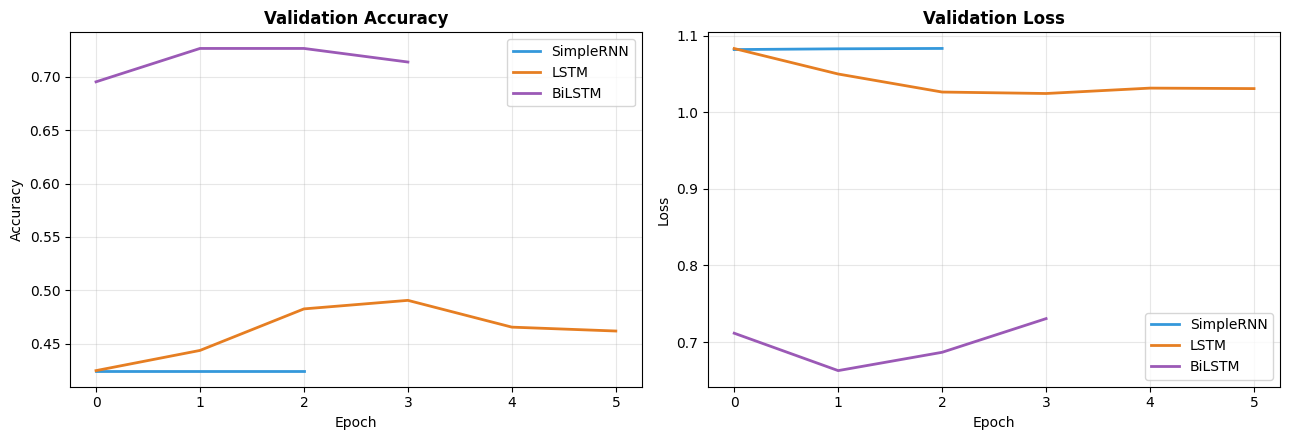

In [14]:
# 학습 곡선 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for hist, name, color in [(history_rnn, 'SimpleRNN', '#3498db'),
                           (history_lstm, 'LSTM', '#e67e22'),
                           (history_bilstm, 'BiLSTM', '#9b59b6')]:
    axes[0].plot(hist.history['val_accuracy'], label=name, color=color, linewidth=2)
    axes[1].plot(hist.history['val_loss'], label=name, color=color, linewidth=2)

axes[0].set_title('Validation Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

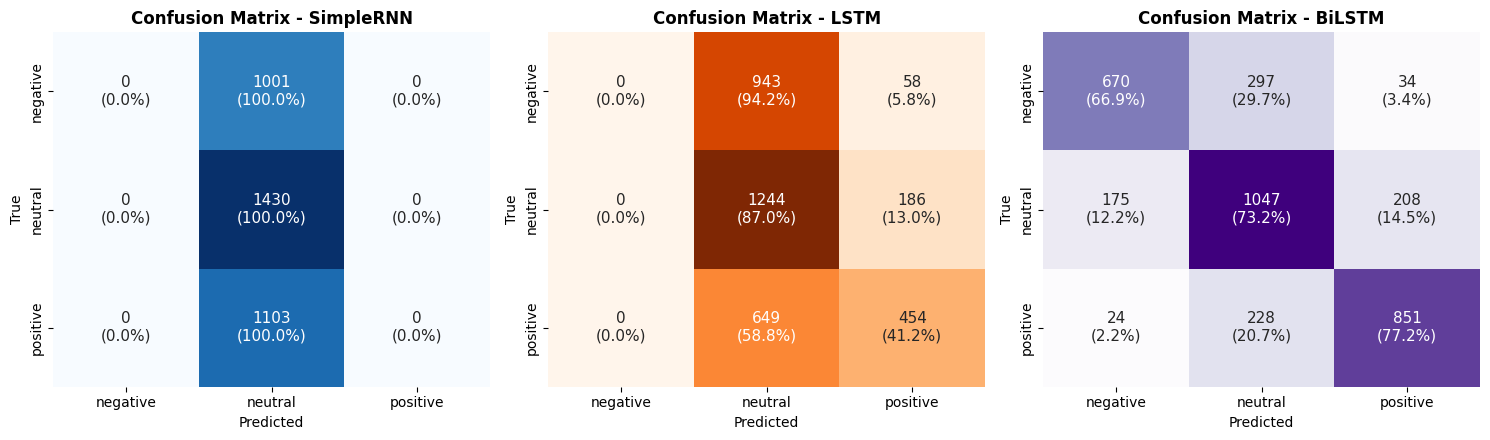

In [15]:
# Confusion matrix 3개 나란히
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_confusion_matrix(y_test, y_pred_rnn,    'SimpleRNN', ax=axes[0], cmap='Blues')
plot_confusion_matrix(y_test, y_pred_lstm,   'LSTM',      ax=axes[1], cmap='Oranges')
plot_confusion_matrix(y_test, y_pred_bilstm, 'BiLSTM',    ax=axes[2], cmap='Purples')
plt.tight_layout(); plt.show()

In [16]:
# 결과 표
df = pd.DataFrame([result_rnn, result_lstm, result_bilstm])
df = df[['model', 'accuracy', 'f1_macro', 'f1_weighted', 'train_time_sec']]
df.columns = ['Model', 'Accuracy', 'F1 (macro)', 'F1 (weighted)', 'Train Time (s)']
df.round(4)

,Model,Accuracy,F1 (macro),F1 (weighted),Train Time (s)
0,SimpleRNN,0.4046,0.1920,0.2331,15.9038
1,LSTM,0.4805,0.3625,0.3933,227.2512
2,BiLSTM,0.7267,0.7297,0.7271,14.5592


In [17]:
# BiLSTM 오분류 사례
show_misclassified(X_test_text, y_test, y_pred_bilstm, n=5)


 오분류 사례 (5개, 전체 966개 중)
------------------------------------------------------------
[True: positive | Pred:  neutral]
  → cinema tonight it is half the price on monday

[True: negative | Pred:  neutral]
  → theres too much light pollution to see the stars

[True: negative | Pred: positive]
  → yea, someone is getting the best of me.

[True: negative | Pred:  neutral]
  → just found mj mouse flats at djs. of course there are none left in my size

[True: negative | Pred:  neutral]
  → okay someplease save me!! now i am watching ninja warrier and eating an egg roll from last night



### 7. 결과 저장 (모델 비교 노트북에서 사용)

In [18]:
results = {
    'SimpleRNN': result_rnn,
    'LSTM': result_lstm,
    'BiLSTM': result_bilstm,
}
with open(os.path.join(RESULTS_DIR, 'result_rnn_lstm.json'), 'w') as f:
    json.dump({k: {kk: float(vv) if isinstance(vv, (int,float,np.floating)) else vv
                   for kk,vv in v.items()} for k,v in results.items()}, f, indent=2)

# 예측값도 저장 (오분류 사례 비교용)
np.savez(os.path.join(RESULTS_DIR, 'preds_rnn_lstm.npz'),
         y_test=y_test,
         pred_rnn=y_pred_rnn,
         pred_lstm=y_pred_lstm,
         pred_bilstm=y_pred_bilstm)
print('result_rnn_lstm.json, preds_rnn_lstm.npz 저장')

result_rnn_lstm.json, preds_rnn_lstm.npz 저장
